## Calculating Virtual Geomagnetic Poles (VGPs) and a mean pole

This notebook illustrates the step of calculating VGPs from site locations (`lat` and `lon`) and site directions (`dir_dec` and `dir_inc`). It then illustrates the step of calculating a mean pole.

In [1]:
!pip install cartopy
!pip install pmagpy

## Import packages

We need `ipmag` and `pmag` for the calculations, `pandas` to deal with tabular data, and `matplotlib` to have some more plotting functionality.

In [2]:
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

## Import site data

I am downloading these data from MagIC. You can instead skip this step if you are importing a local sites.txt files that you have uploaded into Colab.

In [3]:
result, ding_file = ipmag.download_magic_from_id('20603')
ipmag.unpack_magic(ding_file, print_progress=False)

Download successful. File saved to: ./magic_contribution_20603.txt
1  records written to file  /Users/penokean/0000_GitHub/2026_ESCI_pmag_course/W12_paleogeography/contribution.txt
1  records written to file  /Users/penokean/0000_GitHub/2026_ESCI_pmag_course/W12_paleogeography/locations.txt
28  records written to file  /Users/penokean/0000_GitHub/2026_ESCI_pmag_course/W12_paleogeography/sites.txt


True

We can then tell pandas to import the sites.txt file. If you upload your sites.txt to Colab you can skip the previous cell and just run this one.

In [4]:
ding_sites = pd.read_csv('sites.txt', sep='\t', header=1)
ding_sites.head()

,age,age_high,age_low,age_sigma,age_unit,citations,description,dir_alpha95,dir_dec,dir_inc,...,lithologies,location,lon,method_codes,result_quality,site,vgp_dm,vgp_dp,vgp_lat,vgp_lon
0,NaN,780.0,775.0,NaN,Ma,10.1029/2025JB031762,NaN,9.9,265.2,-11.4,...,Diabase,Gunbarrel LIP,250.116,LP-DIR-T:DE-BFL:DE-FM,g,BT50,NaN,NaN,NaN,NaN
1,NaN,780.0,775.0,NaN,Ma,10.1029/2025JB031762,NaN,9.9,267.4,-15.1,...,Diabase,Gunbarrel LIP,250.116,LP-DIR-T:DE-BFL:DE-FM,g,BT50,10.2,5.2,-7.3,156.5
2,NaN,780.0,775.0,NaN,Ma,10.1029/2025JB031762,NaN,8.2,268.7,5.1,...,Diabase,Gunbarrel LIP,250.117,LP-DIR-T:DE-BFL:DE-FM,g,BT51,NaN,NaN,NaN,NaN
3,NaN,780.0,775.0,NaN,Ma,10.1029/2025JB031762,NaN,8.2,268.1,1.7,...,Diabase,Gunbarrel LIP,250.117,LP-DIR-T:DE-BFL:DE-FM,g,BT51,8.2,4.1,-0.7,162.1
4,NaN,780.0,775.0,NaN,Ma,10.1029/2025JB031762,NaN,14.0,267.2,-18.5,...,Diabase,Gunbarrel LIP,250.089,LP-DIR-T:DE-BFL:DE-FM,g,BT54,NaN,NaN,NaN,NaN


## Convert directions to Virtual Geomagnetic Poles (VGPs)

Each site-mean direction is converted to a VGP using the **dipole formula**. The procedure is:

1. Calculate the magnetic **colatitude** $p$ (angular distance from site to pole) from the inclination $I_m$ using the dipole equation:

$$p = \cot^{-1}\left(\frac{\tan I_m}{2}\right) = \tan^{-1}\left(\frac{2}{\tan I_m}\right)$$

2. Calculate the pole **latitude** $\lambda_p$:

$$\lambda_p = \sin^{-1}(\sin \lambda_s \cos p + \cos \lambda_s \sin p \cos D_m)$$

3. Calculate the pole **longitude** $\phi_p$ (with a sign test on $\beta$):

$$\beta = \sin^{-1}\left(\frac{\sin p \sin D_m}{\cos \lambda_p}\right)$$

The function `pmag.dia_vgp()` from PmagPy handles all of this. It also returns *dp* and *dm*, the semi-axes of the confidence ellipse about the pole.

## Look at the docstring for `pmag.dia_vgp` to see what it needs.

In [5]:
pmag.dia_vgp?

Signature: pmag.dia_vgp(*args)
Docstring:
Converts directional data (declination, inclination, alpha95) at a given
location (Site latitude, Site longitude) to pole position (pole longitude,
pole latitude, dp, dm).

Parameters
----------
Takes input as (Dec, Inc, a95, Site latitude, Site longitude)
Input can be as individual values (5 parameters)
or
as a list of lists: [[Dec, Inc, a95, lat, lon],[Dec, Inc, a95, lat, lon]]

Returns
-------
if input is individual values for one pole the return is:
pole longitude, pole latitude, dp, dm

if input is list of lists the return is:
list of pole longitudes, list of pole latitudes, list of dp, list of dm

Examples
--------
>>> pmag.dia_vgp(4, 41, 0, 33, -117)
(41.68629415047637, 79.86259998889103, 0.0, 0.0)
File:      ~/0000_GitHub/PmagPy/pmagpy/pmag.py
Type:      function


## Put the values together

From the docstring we can see that the function needs a list of lists: `[[Dec, Inc, a95, lat, lon],[Dec, Inc, a95, lat, lon]]`. We can pull those values out of the dataframe like this:

In [6]:
site_dir_list = ding_sites[
    ["dir_dec", "dir_inc", "dir_alpha95", "lat", "lon"]
].values.tolist()

and then look at it to make sure it is right

In [7]:
site_dir_list

[[265.2, -11.4, 9.9, 45.028, 250.116],
 [267.4, -15.1, 9.9, 45.028, 250.116],
 [268.7, 5.1, 8.2, 45.027, 250.117],
 [268.1, 1.7, 8.2, 45.027, 250.117],
 [267.2, -18.5, 14.0, 45.102, 250.089],
 [270.7, -21.8, 14.0, 45.102, 250.089],
 [275.5, 7.8, 10.2, 45.102, 250.091],
 [274.4, 5.5, 10.2, 45.102, 250.091],
 [264.2, 14.4, 11.9, 45.095, 250.091],
 [262.2, 10.2, 11.9, 45.095, 250.091],
 [256.5, 5.5, 9.5, 45.034, 250.338],
 [256.1, 0.2, 9.5, 45.034, 250.338],
 [289.0, -35.3, 5.7, 45.004, 250.369],
 [296.0, -34.5, 5.7, 45.004, 250.369],
 [263.7, 5.9, 10.3, 45.034, 250.339],
 [263.1, 1.7, 10.3, 45.034, 250.339],
 [289.6, -29.6, 4.7, 44.96, 250.612],
 [295.2, -28.8, 4.7, 44.96, 250.612],
 [288.3, -21.8, 7.9, 44.971, 250.555],
 [292.3, -21.4, 7.9, 44.971, 250.555],
 [285.6, 11.5, 10.2, 43.818, 249.258],
 [285.5, 1.5, 10.2, 43.818, 249.258],
 [281.0, 3.0, 6.0, 65.667, 241.857],
 [281.0, 3.0, 6.0, 65.667, 241.857],
 [280.4, 16.1, 20.0, 64.401, 242.868],
 [280.4, 16.1, 20.0, 64.401, 242.868],
 [2

## Calculate the VGPs

In [8]:
vgp_lon, vgp_lat, dp, dm = pmag.dia_vgp(site_dir_list)

and look at the values for `vgp_lon` that result.

In [18]:
vgp_lon

[159.42284807841216,
 156.49272943957573,
 162.84228523179218,
 162.06214551076565,
 155.31115980353715,
 151.5680649304261,
 158.9658756957219,
 158.92103590508728,
 169.35086292417708,
 169.24405111793712,
 171.91498337146243,
 170.34014947123595,
 133.42800991943193,
 128.7676768488781,
 166.8905998569482,
 165.8330128178545,
 135.67536476085127,
 131.91267767888127,
 139.6104416298113,
 136.82034171057606,
 152.578736143101,
 148.9315638119294,
 142.42551053551244,
 142.42551053551244,
 147.0370652720067,
 147.0370652720067,
 146.44318688626484,
 146.44318688626484]

### Add calculated vgp values to the dataframe

In [19]:
ding_sites['vgp_lat'] = vgp_lat
ding_sites['vgp_lon'] = vgp_lon
ding_sites['vgp_dp'] = dp
ding_sites['vgp_dm'] = dm

### Look at the updated dataframe

`.head()` shows us the first 5 rows.

In [20]:
ding_sites.head()

,age,age_high,age_low,age_sigma,age_unit,citations,description,dir_alpha95,dir_dec,dir_inc,...,lithologies,location,lon,method_codes,result_quality,site,vgp_dm,vgp_dp,vgp_lat,vgp_lon
0,NaN,780.0,775.0,NaN,Ma,10.1029/2025JB031762,NaN,9.9,265.2,-11.4,...,Diabase,Gunbarrel LIP,250.116,LP-DIR-T:DE-BFL:DE-FM,g,BT50,10.048309,5.099420,-7.458378,159.422848
1,NaN,780.0,775.0,NaN,Ma,10.1029/2025JB031762,NaN,9.9,267.4,-15.1,...,Diabase,Gunbarrel LIP,250.116,LP-DIR-T:DE-BFL:DE-FM,g,BT50,10.161984,5.215451,-7.259226,156.492729
2,NaN,780.0,775.0,NaN,Ma,10.1029/2025JB031762,NaN,8.2,268.7,5.1,...,Diabase,Gunbarrel LIP,250.117,LP-DIR-T:DE-BFL:DE-FM,g,BT51,8.224408,4.124444,0.889175,162.842285
3,NaN,780.0,775.0,NaN,Ma,10.1029/2025JB031762,NaN,8.2,268.1,1.7,...,Diabase,Gunbarrel LIP,250.117,LP-DIR-T:DE-BFL:DE-FM,g,BT51,8.202708,4.102708,-0.741062,162.062146
4,NaN,780.0,775.0,NaN,Ma,10.1029/2025JB031762,NaN,14.0,267.2,-18.5,...,Diabase,Gunbarrel LIP,250.089,LP-DIR-T:DE-BFL:DE-FM,g,BT54,14.560535,7.571756,-8.678573,155.311160


### Export the updated dataframe

In [12]:
ding_sites.to_csv("sites_with_vgp.txt", sep="\t", index=False)

## Calculate mean pole

### Filter to just be tilt corrected data

For some of your data sets you will use data that are not tilt corrected. In this case, we need to use the tilt corrected data (i.e. the sites where `['dir_tilt_correction'] == 100`)

In [13]:
ding_sites_tilt_corrected = ding_sites[ding_sites['dir_tilt_correction'] == 100]

We can then pull out a list of the tilt corrected vgp_lat and vgp_lon values>

In [14]:
vgp_lat_tc = ding_sites_tilt_corrected['vgp_lat'].tolist()
vgp_lon_tc = ding_sites_tilt_corrected['vgp_lon'].tolist()

### Use `ipmag.fisher_mean` to calculate mean pole

In [21]:
mean_pole = ipmag.fisher_mean(dec=vgp_lon_tc, inc=vgp_lat_tc)
ipmag.print_pole_mean(mean_pole)

Plon: 151.2  Plat: 3.0
Number of directions in mean (n): 14
Angular radius of 95% confidence (A_95): 7.9
Precision parameter (k) estimate: 26.3


`mean_pole` is a dictionary and we can extract the mean pole longitude, latitude, and A95 uncertainty as single values

In [16]:
mean_pole_lon = mean_pole['dec']
mean_pole_lat = mean_pole['inc']
mean_pole_A95 = mean_pole['alpha95']

### plot the pole

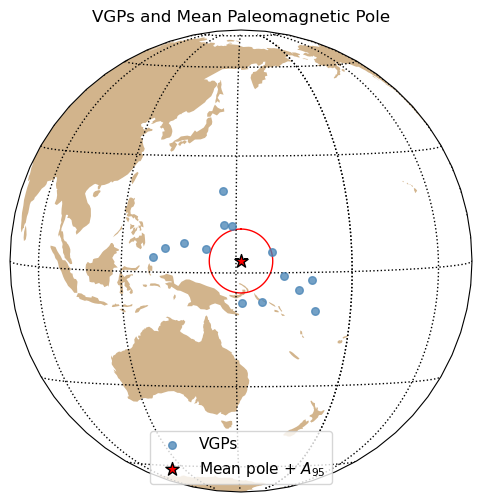

In [17]:
map_axis = ipmag.make_orthographic_map(central_longitude=mean_pole['dec'],
                                       central_latitude=mean_pole['inc'],
                                       figsize=(6, 6),
                                       land_edge_color=None)

# Plot individual VGPs
ipmag.plot_vgp(map_axis, vgp_lon=vgp_lon_tc, vgp_lat=vgp_lat_tc,
               color='steelblue', markersize=30, zorder=20, edge=None, alpha=0.75, 
               label='VGPs')

# Plot mean pole with A95 confidence circle
ipmag.plot_pole(map_axis, mean_pole_lon, mean_pole_lat, mean_pole_A95,
                marker='*', color='red', markersize=100, zorder=30, 
                label='Mean pole + $A_{95}$')

plt.legend(loc='lower center', fontsize=11)

plt.title('VGPs and Mean Paleomagnetic Pole')
plt.show()